# Aprendizaje supervisado: árbol de clasificación

## ¿una persona reincidirá durante su libertad condicional?

En este notebook se construye y evalúa un **árbol de decisión**. El objetivo es predecir la variable `reincidencia` a partir de características como edad, empleo, antecedentes y apoyo familiar.

> **Nota ética:** este ejemplo es educativo. Un modelo no debe usarse por sí solo para tomar decisiones judiciales o que afecten derechos de las personas.

## 1. Importar librerías

`pandas` permite manejar tablas de datos; `scikit-learn` aporta el modelo y las métricas; `matplotlib` se utiliza para las gráficas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

## 2. Cargar y explorar la base de datos

Cambia la ruta por la ubicación de tu archivo `base_seguridad_reincidencia.csv`. Antes de entrenar, comprobamos sus primeras filas, los tipos de datos y el equilibrio de la variable objetivo.

In [3]:
RUTA_DATOS = r"datos\base_seguridad_reincidencia.csv"  # <-- edita esta ruta
datos = pd.read_csv(RUTA_DATOS)

display(datos.head())
datos.info()

print("\nConteo de la variable objetivo:")
display(datos['reincidencia'].value_counts())
display(datos['reincidencia'].value_counts(normalize=True).mul(100).round(1))

,edad,delito_previo,num_delitos_previos,meses_en_prision,empleo,apoyo_familiar,consumo_sustancias,nivel_educativo,supervision_post,reincidencia
0,56,Robo,1,28,No,Si,No,Universidad,Media,No
1,46,Violencia_familiar,2,25,Si,No,No,Secundaria,Baja,Si
2,32,Robo,0,45,No,Si,No,Preparatoria,Baja,No
3,60,Narcomenudeo,2,15,Si,No,No,Preparatoria,Baja,No
4,25,Violencia_familiar,1,30,No,Si,Si,Secundaria,Media,Si


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   edad                 1000 non-null   int64
 1   delito_previo        1000 non-null   str  
 2   num_delitos_previos  1000 non-null   int64
 3   meses_en_prision     1000 non-null   int64
 4   empleo               1000 non-null   str  
 5   apoyo_familiar       1000 non-null   str  
 6   consumo_sustancias   1000 non-null   str  
 7   nivel_educativo      1000 non-null   str  
 8   supervision_post     1000 non-null   str  
 9   reincidencia         1000 non-null   str  
dtypes: int64(3), str(7)
memory usage: 109.6 KB

Conteo de la variable objetivo:


reincidencia
No    620
Si    380
Name: count, dtype: int64

reincidencia
No    62.0
Si    38.0
Name: proportion, dtype: float64

## 3. Preparar las variables

La variable que queremos predecir se llama **objetivo** (`y`); las demás son las variables predictoras (`X`).

Los algoritmos de scikit-learn trabajan con números. Por eso: 

- `LabelEncoder` convierte `No` / `Sí` de la variable objetivo en 0 / 1.
- `get_dummies` crea columnas binarias para las categorías de las variables predictoras.

In [4]:
le_objetivo = LabelEncoder()
y = le_objetivo.fit_transform(datos['reincidencia'])

X = datos.drop(columns='reincidencia')
columnas_categoricas = [
    'delito_previo', 'empleo', 'apoyo_familiar',
    'consumo_sustancias', 'nivel_educativo', 'supervision_post'
]
X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

print('Clases codificadas:', dict(enumerate(le_objetivo.classes_)))
print('Dimensión de X:', X.shape)
display(X.head())

Clases codificadas: {0: 'No', 1: 'Si'}
Dimensión de X: (1000, 20)


,edad,num_delitos_previos,meses_en_prision,delito_previo_Fraude,delito_previo_Narcomenudeo,delito_previo_Robo,delito_previo_Violencia_familiar,empleo_No,empleo_Si,apoyo_familiar_No,apoyo_familiar_Si,consumo_sustancias_No,consumo_sustancias_Si,nivel_educativo_Preparatoria,nivel_educativo_Primaria,nivel_educativo_Secundaria,nivel_educativo_Universidad,supervision_post_Alta,supervision_post_Baja,supervision_post_Media
0,56,1,28,0,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1
1,46,2,25,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0,1,0
2,32,0,45,0,0,1,0,1,0,0,1,1,0,1,0,0,0,0,1,0
3,60,2,15,0,1,0,0,0,1,1,0,1,0,1,0,0,0,0,1,0
4,25,1,30,0,0,0,1,1,0,0,1,0,1,0,0,1,0,0,0,1


## 4. Separar los datos: entrenamiento y prueba

Se reserva el 20 % de los registros para medir el desempeño con casos que el modelo no vio al entrenar. `stratify=y` conserva aproximadamente la misma proporción de reincidencia en ambos conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=17, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} personas')
print(f'Prueba:        {X_test.shape[0]} personas')

Entrenamiento: 800 personas
Prueba:        200 personas


## 5. Entrenar el árbol de decisión

El árbol aprende reglas del tipo *«si la edad es menor que…»*. Se limita su profundidad y el tamaño mínimo de las hojas para reducir el sobreajuste.

`class_weight='balanced'` da mayor peso a la clase menos frecuente. Esto ayuda cuando hay muchas más personas que no reinciden que personas que sí reinciden.

In [6]:
arbol = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=17
)
arbol.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",17
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are co

## 6. Interpretar la importancia de las variables

La importancia indica cuánto contribuyó cada columna a las decisiones del árbol. No implica causalidad: una variable importante para la predicción no demuestra que sea la causa de la reincidencia.

,importancia
empleo_Si,0.399879
num_delitos_previos,0.194655
consumo_sustancias_Si,0.130744
apoyo_familiar_Si,0.124346
consumo_sustancias_No,0.086001
apoyo_familiar_No,0.047477
edad,0.014597
supervision_post_Baja,0.002300


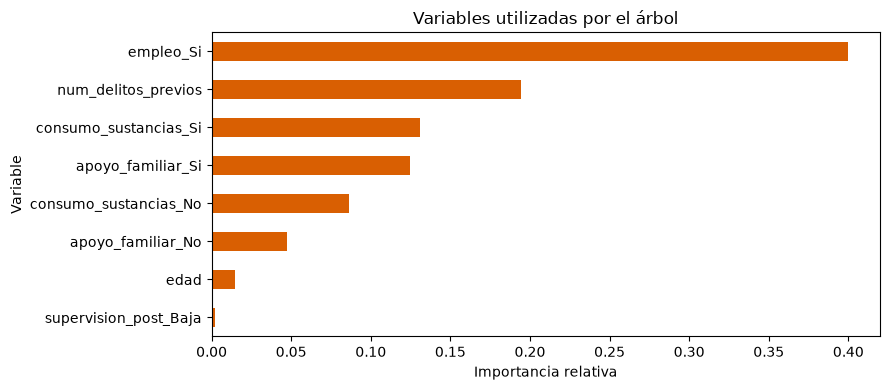

In [7]:
importancias = pd.Series(arbol.feature_importances_, index=X.columns).sort_values()
importancias_activas = importancias[importancias > 0]

display(importancias_activas.sort_values(ascending=False).to_frame('importancia'))

fig, ax = plt.subplots(figsize=(9, max(4, len(importancias_activas) * 0.45)))
importancias_activas.plot.barh(ax=ax, color='#d95f02')
ax.set_title('Variables utilizadas por el árbol')
ax.set_xlabel('Importancia relativa')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

## 7. Predecir y evaluar

La matriz de confusión compara la clase real (filas) con la predicción (columnas). Además de la exactitud, conviene revisar *precision*, *recall* y F1 para cada clase, especialmente si las clases están desbalanceadas.

# Ejemplo
Por esta razón, el F1-score resulta especialmente útil cuando existe un desequilibrio entre las clases, por ejemplo:

15% de pacientes con una enfermedad

85% de pacientes sanos

Este tipo de distribución es muy frecuente en el ámbito sanitario, donde la clase minoritaria suele ser precisamente la más importante.

El F1-score se calcula como la media armónica entre precisión y recall, penalizando modelos que optimizan una métrica a costa de la otra.

Exactitud general: 0.775

              precision    recall  f1-score   support

          No       0.83      0.81      0.82       124
          Si       0.70      0.72      0.71        76

    accuracy                           0.78       200
   macro avg       0.76      0.77      0.76       200
weighted avg       0.78      0.78      0.78       200



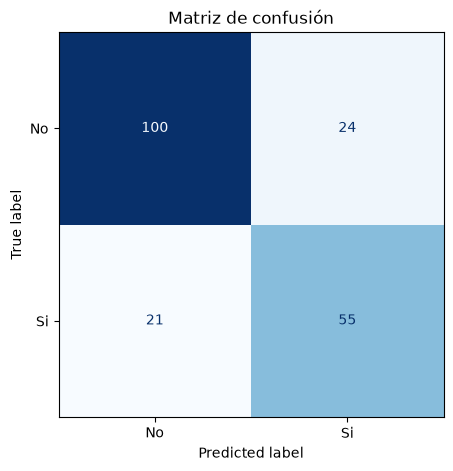

In [8]:
pred_arbol = arbol.predict(X_test)

print(f'Exactitud general: {accuracy_score(y_test, pred_arbol):.3f}\n')
print(classification_report(y_test, pred_arbol, target_names=le_objetivo.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_arbol, display_labels=le_objetivo.classes_,
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Matriz de confusión')
plt.show()

## 8. Visualizar el árbol

En cada caja aparece la regla de división, la impureza Gini, el número de registros y la clase predominante. Las ramas izquierdas representan que la condición se cumple (`True`) y las derechas que no se cumple (`False`).

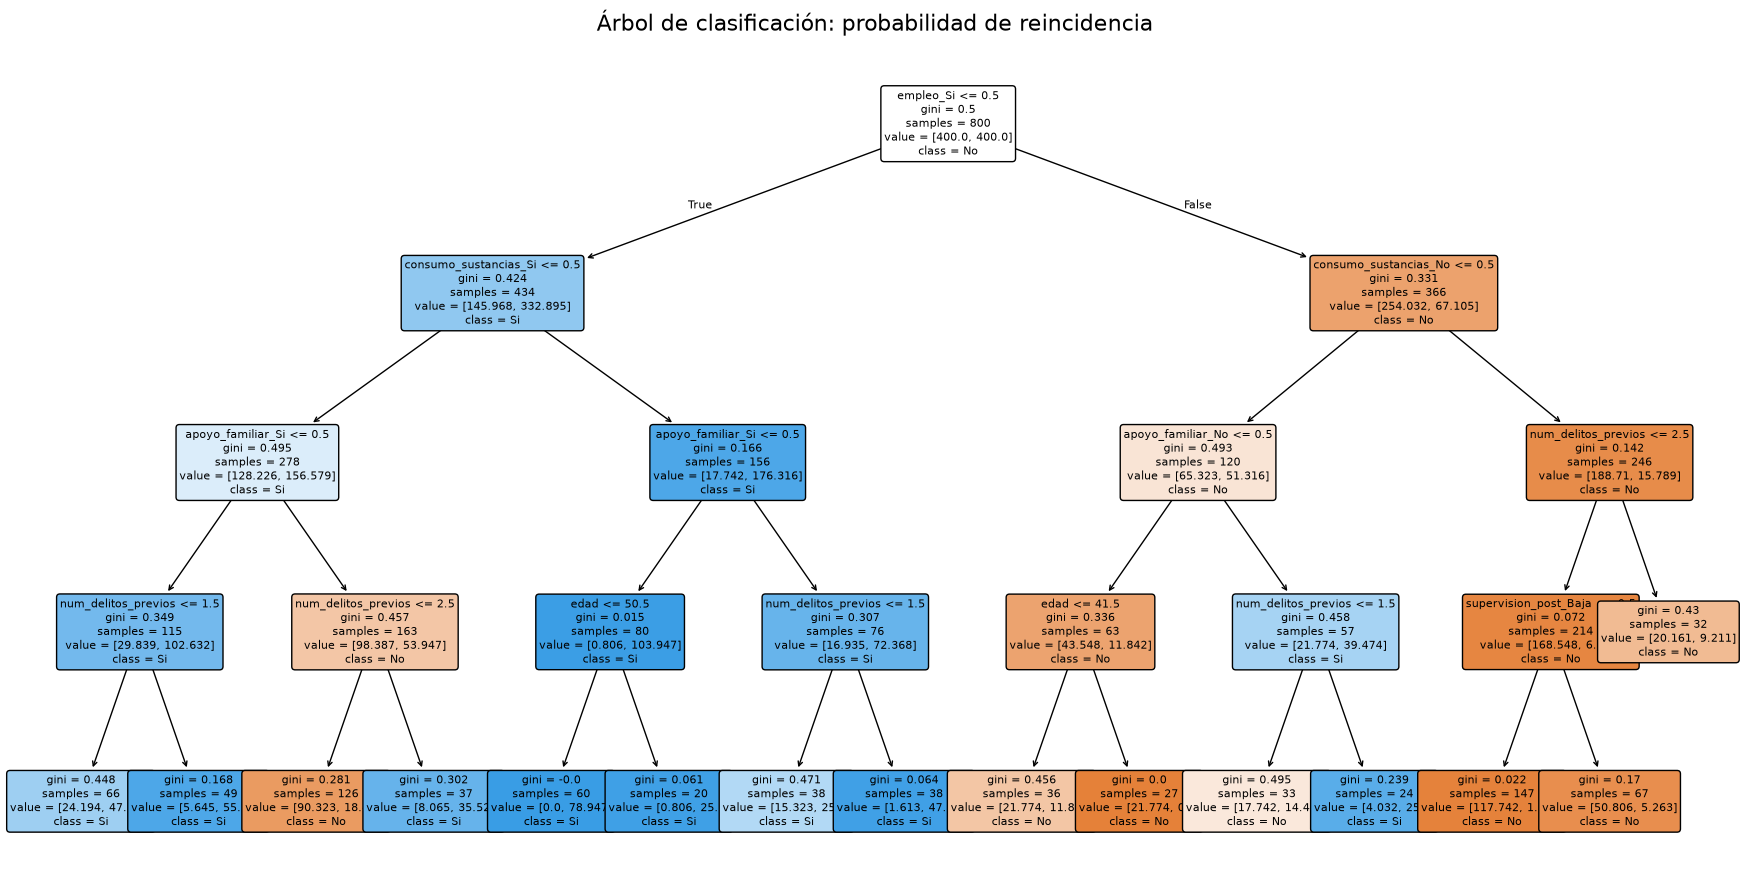

In [9]:
plt.figure(figsize=(22, 11))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=le_objetivo.classes_,
    filled=True,
    rounded=True,
    proportion=False,
    fontsize=8
)
plt.title('Árbol de clasificación: probabilidad de reincidencia', fontsize=16)
plt.show()

## Conclusión

El flujo completo fue: cargar datos → codificar categorías → separar entrenamiento/prueba → entrenar → evaluar → interpretar. Para mejorar el análisis se pueden comparar diferentes valores de `max_depth` y medir también validación cruzada.